<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Francois-Projet/Entrainement_Model_RestNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=20ab5d3d-623d-4f3b-94d2-ffbf4a9dcff2
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:01<00:00, 74.1MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [2]:
import os

import shutil

from pathlib import Path

# =====================================

# CHEMINS

# =====================================

src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import

dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]

tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]

no_tumor_folder = "no_tumor"

# =====================================

# NETTOYAGE SI LE DOSSIER EXISTE DEJA

# =====================================

if dst_root.exists():

    shutil.rmtree(dst_root)

# =====================================

# CREATION DES DOSSIERS DE DESTINATION

# =====================================

for split in splits:

    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)

    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================

# FONCTION DE COPIE SECURISEE

# =====================================

def safe_copy(src_file: Path, dst_dir: Path):

    dst_file = dst_dir / src_file.name

    if dst_file.exists():

        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"

    shutil.copy2(src_file, dst_file)

# =====================================

# FUSION DES CLASSES EN BINAIRE

# =====================================

for split in splits:

    # Fusion des classes tumor

    for cls in tumor_folders:

        cls_path = src_root / split / cls

        if cls_path.exists():

            for img in cls_path.rglob("*"):

                if img.is_file():

                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor

    cls_path = src_root / split / no_tumor_folder

    if cls_path.exists():

        for img in cls_path.rglob("*"):

            if img.is_file():

                safe_copy(img, dst_root / split / "no_tumor")

# =====================================

# VERIFICATION

# =====================================

print("✅ Fusion binaire terminée.")

print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))

print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))

print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))

print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))

print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))




✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['tumor', 'no_tumor']
Testing classes  : ['tumor', 'no_tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [3]:
import tensorflow as tf

import os

# ==============================

# CHEMINS DU DATASET BINAIRE

# ==============================

train_dir = "/content/Binary/Training"

test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))

print("Classes test  :", os.listdir(test_dir))

# ==============================

# CHARGEMENT DU DATASET TRAIN

# ==============================

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=True,

    seed=42

)

# ==============================

# CHARGEMENT DU DATASET TEST

# ==============================

test_ds = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=False

)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [4]:
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = Path("/content/Binary/Training")
test_dir  = Path("/content/Binary/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0
    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1
    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_dir)
removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [5]:
# Equilibrer le data  d entrainement

import shutil

import numpy as np

from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# =====================================

# DOSSIERS SOURCE

# =====================================

train_no = Path("/content/Binary/Training/no_tumor")

train_tu = Path("/content/Binary/Training/tumor")

# =====================================

# DOSSIERS DESTINATION EQUILIBRES

# =====================================

balanced_root = Path("/content/Binary/Training_balanced")

balanced_no = balanced_root / "no_tumor"

balanced_tu = balanced_root / "tumor"

# Nettoyage si le dossier existe déjà

if balanced_root.exists():

    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)

balanced_tu.mkdir(parents=True, exist_ok=True)

# =====================================

# LISTE DES IMAGES

# =====================================

no_files = list(train_no.glob("*"))

tu_files = list(train_tu.glob("*"))

n_no = len(no_files)

n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)

print("Nombre initial tumor    :", n_tu)

# =====================================

# COPIE DES IMAGES ORIGINALES

# =====================================

for f in no_files:

    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:

    shutil.copy2(f, balanced_tu / f.name)

# =====================================

# DATA AUGMENTATION

# =====================================

datagen = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.10,

    horizontal_flip=True,

    fill_mode='nearest'

)

# =====================================

# FONCTION POUR GENERER JUSQU'A EQUILIBRE

# =====================================

def augment_until_target(files, output_dir, target_count, prefix):

    current_count = len(list(output_dir.glob("*")))

    i = 0

    while current_count < target_count:

        img_path = files[i % len(files)]

        img = load_img(img_path, target_size=(224, 224))

        x = img_to_array(img)

        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)

        aug_img = next(aug_iter)[0].astype("uint8")

        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"

        save_img(save_path, aug_img)

        current_count += 1

        i += 1

# =====================================

# EQUILIBRAGE

# =====================================

target = max(n_no, n_tu)

if n_no < target:

    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:

    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage terminé")

print("no_tumor final :", len(list(balanced_no.glob('*'))))

print("tumor final    :", len(list(balanced_tu.glob('*'))))


Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage terminé
no_tumor final : 2475
tumor final    : 2475


In [6]:
# Charger le ytrain equilibre plus test
import tensorflow as tf
import os

balanced_train_dir = "/content/Binary/Training_balanced"
test_dir = "/content/Binary/Testing"

print("Classes train équilibré :", os.listdir(balanced_train_dir))
print("Classes test            :", os.listdir(test_dir))

Classes train équilibré : ['tumor', 'no_tumor']
Classes test            : ['tumor', 'no_tumor']


In [7]:
# Créer train et validation à partir du train équilibré
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Noms des classes :", train_ds.class_names)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Noms des classes : ['no_tumor', 'tumor']


In [8]:
# Normalisation
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# ==============================
# COUCHE DE NORMALISATION
# ==============================
normalization_layer = tf.keras.layers.Rescaling(1./255)

# ==============================
# APPLICATION SUR LES DATASETS
# ==============================
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# ==============================
# OPTIMISATION DU PIPELINE
# ==============================
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Normalisation terminée (pixels entre 0 et 1)")

✅ Normalisation terminée (pixels entre 0 et 1)


/tmp/ipykernel_7203/559467833.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[i].numpy())}")


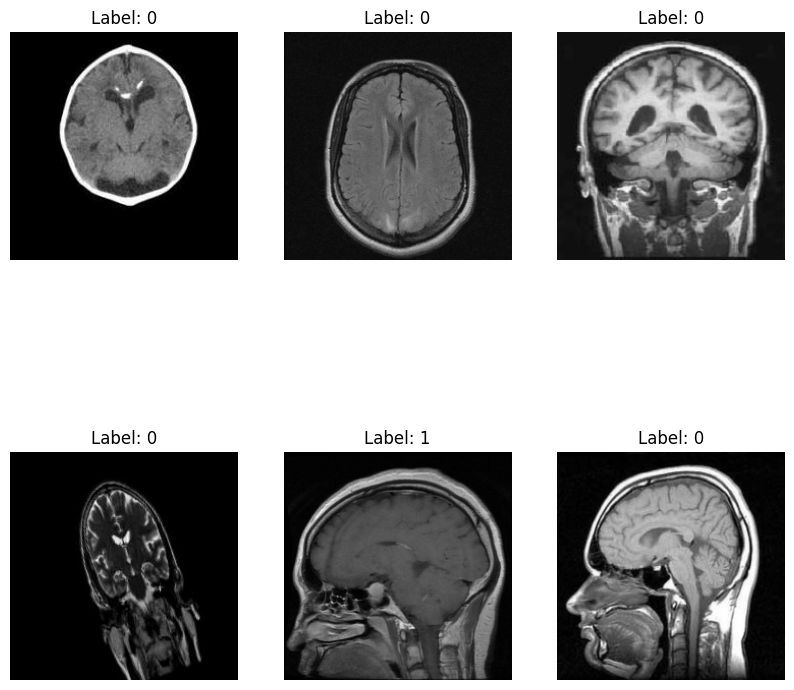

In [9]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {int(labels[i].numpy())}")
        plt.axis("off")
    plt.show()

In [10]:
# Nettoyer la memoire
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()


0

In [11]:
# recharger les data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes :", train_ds.class_names)

# Sauvegarde des classes
class_names = train_ds.class_names

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


In [12]:
#Optimiser le pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

In [13]:
# Modele resNet50
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Base ResNet50
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Modèle complet
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [14]:
# Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# Callsbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ModelCheckpoint("/content/resnet50_best.keras", save_best_only=True)
]

In [16]:
#Entraînement avec class_weight
class_weight = {
    0: 1.0,
    1: 1.5
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.8634 - loss: 0.4225 - val_accuracy: 0.9535 - val_loss: 0.1542 - learning_rate: 1.0000e-04
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - accuracy: 0.9366 - loss: 0.2136 - val_accuracy: 0.9697 - val_loss: 0.0984 - learning_rate: 1.0000e-04
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.9528 - loss: 0.1501 - val_accuracy: 0.9778 - val_loss: 0.0760 - learning_rate: 1.0000e-04
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 0.9568 - loss: 0.1423 - val_accuracy: 0.9828 - val_loss: 0.0609 - learning_rate: 1.0000e-04
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.9684 - loss: 0.1072 - val_accuracy: 0.9838 - val_loss: 0.0533 - learning_rate: 1.0000e-04
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.9745 - loss: 0.0949 - val_accuracy: 0.9848 - val_loss: 0.0477 - learning_rate: 1.0000e-04
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 18

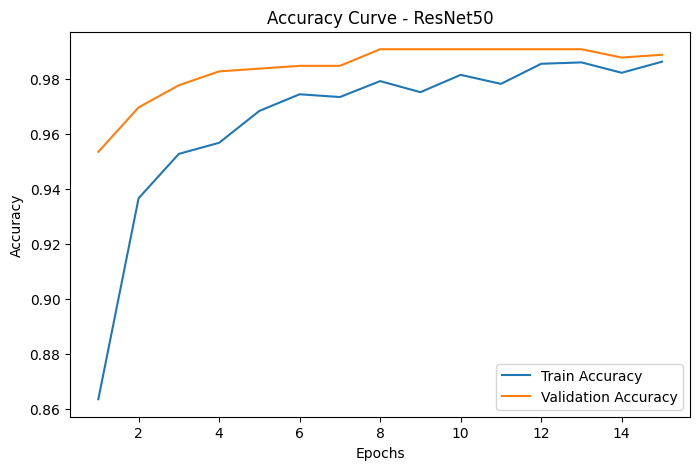

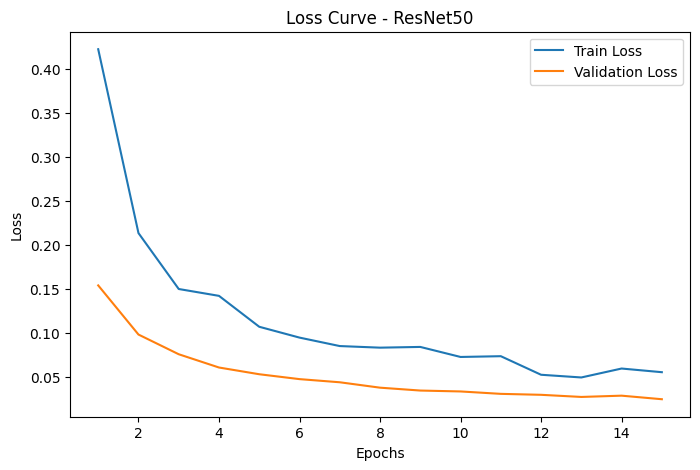

In [17]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve - ResNet50")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve - ResNet50")
plt.legend()
plt.show()

In [18]:
# Evaluation
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy ResNet50 : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.8858 - loss: 0.3106
Test Accuracy ResNet50 : 0.8858


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 261ms/step

===== Seuil = 0.5 =====
Precision tumor : 0.9919354838709677
Recall tumor    : 0.8512110726643599
F1-score tumor  : 0.9162011173184358
Matrice de confusion :
[[103   2]
 [ 43 246]]

===== Seuil = 0.4 =====
Precision tumor : 0.9921875
Recall tumor    : 0.8788927335640139
F1-score tumor  : 0.9321100917431193
Matrice de confusion :
[[103   2]
 [ 35 254]]

===== Seuil = 0.3 =====
Precision tumor : 0.9847328244274809
Recall tumor    : 0.8927335640138409
F1-score tumor  : 0.9364791288566243
Matrice de confusion :
[[101   4]
 [ 31 258]]

===== Seuil = 0.2 =====
Precision tumor : 0.9676258992805755
Recall tumor    : 0.9307958477508651
F1-score tumor  : 0.9488536155202821
Matrice de confusion :
[[ 96   9]
 [ 20 269]]

✅ Meilleur seuil choisi : 0.2

📊 Classification Report final :
              precision    recall  f1-score   support

    no_tumor       0.83      0.91      0.87       105
       tumor       0.97      0.93      0.95       289

    accuracy

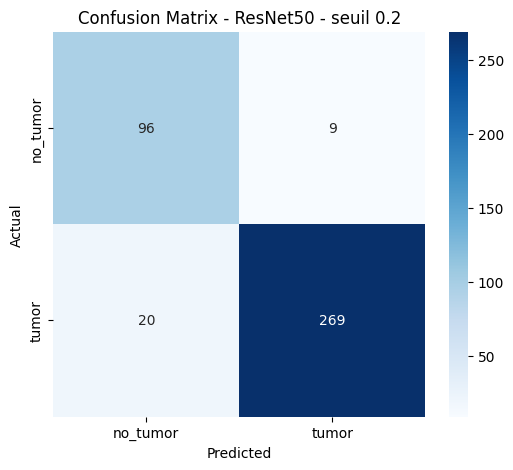

In [19]:
# Opimisation avec seuil
# Optimisation du seuil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# ==============================
# VRAIES ETIQUETTES + PROBABILITES
# ==============================
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

# ==============================
# TEST DE PLUSIEURS SEUILS
# ==============================
thresholds = [0.5, 0.4, 0.3, 0.2]
results = []

for threshold in thresholds:
    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    print(f"\n===== Seuil = {threshold} =====")
    print("Precision tumor :", precision)
    print("Recall tumor    :", recall)
    print("F1-score tumor  :", f1)
    print("Matrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

    results.append((threshold, precision, recall, f1))

# ==============================
# CHOIX DU MEILLEUR SEUIL
# ==============================
best_threshold = max(results, key=lambda x: x[2])[0]  # basé sur F1-score
print("\n✅ Meilleur seuil choisi :", best_threshold)

# ==============================
# RESULTAT FINAL
# ==============================
y_pred_best = (y_prob > best_threshold).astype(int)

print("\n📊 Classification Report final :")
print(classification_report(y_true, y_pred_best, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - ResNet50 - seuil {best_threshold}")
plt.show()

Le modèle ResNet50 présente une convergence stable, comme le montrent les courbes d’apprentissage où les performances d’entraînement et de validation restent proches, indiquant une bonne généralisation sans surapprentissage significatif. La diminution progressive de la fonction de perte confirme un apprentissage efficace du modèle. Ces résultats suggèrent que ResNet50 est capable de capturer correctement les caractéristiques des images IRM. Cependant, une analyse complémentaire des performances (matrice de confusion et recall de la classe tumor) est nécessaire pour évaluer son adéquation en contexte médical.